# The purpose of this file is to perform a QA/QC check of the pipeline over the Gampian-2022-2023 file

Check that the files exists first

In [113]:
from pathlib import Path

p = Path("/Users/djimra/MSc Data Science Jan 2025/Thesis documents/RAG_Pipeline_Project/data_processed/Grampian-2022-2023/chunks.parquet")

print("exists:", p.exists())
print("is_file:", p.is_file())
print("is_dir :", p.is_dir())

exists: True
is_file: True
is_dir : False


We can now inspect the chuncks.parquet files by looking at the first 5 elements.

In [114]:
import pyarrow.parquet as pq

path = (
    "/Users/djimra/MSc Data Science Jan 2025/Thesis documents/"
    "RAG_Pipeline_Project/data_processed/Grampian-2022-2023/chunks.parquet"
)

df = pq.read_table(path).to_pandas()
df.head()

,doc_id,corpus_id,report_year,report_year_source,period_end_date,run_date_utc,chunk_id,chunk_id_global,part,section_title,page_start,page_end,pages,page_list,chunk_text,chunk_tokens,word_count,is_table_like,many_numbers
0,Grampian-2022-2023,Grampian-2022-2023,2022-2023,filename,None,2026-02-03T16:14:57+00:00,p0002_000,Grampian-2022-2023:p0002_000,Unknown,Performance Report,2,2,[2],[{'element': 2}],Page Performance Report 2 a) Overview 7 b) Per...,137,98,False,False
1,Grampian-2022-2023,Grampian-2022-2023,2022-2023,filename,None,2026-02-03T16:14:57+00:00,p0003_000,Grampian-2022-2023:p0003_000,Unknown,NHS GRAMPIAN,3,3,[3],[{'element': 3}],PERFORMANCE REPORT A OVERVIEW 1. Purpose This ...,320,274,False,False
2,Grampian-2022-2023,Grampian-2022-2023,2022-2023,filename,None,2026-02-03T16:14:57+00:00,p0003_001,Grampian-2022-2023:p0003_001,Unknown,NHS GRAMPIAN,3,3,[3],[{'element': 3}],"a very busy and difficult time. However, I kno...",303,272,False,False
3,Grampian-2022-2023,Grampian-2022-2023,2022-2023,filename,None,2026-02-03T16:14:57+00:00,p0004_000,Grampian-2022-2023:p0004_000,Unknown,NHS GRAMPIAN,4,4,[4],[{'element': 4}],PERFORMANCE REPORT A OVERVIEW 19 and transform...,320,286,False,False
4,Grampian-2022-2023,Grampian-2022-2023,2022-2023,filename,None,2026-02-03T16:14:57+00:00,p0004_001,Grampian-2022-2023:p0004_001,Unknown,NHS GRAMPIAN,4,4,[4],[{'element': 4}],budget using one-off income and savings. This ...,217,197,False,False


## Confirm structural sanity

In [115]:
print(df.shape)
print(df.columns)

(278, 19)
Index(['doc_id', 'corpus_id', 'report_year', 'report_year_source',
       'period_end_date', 'run_date_utc', 'chunk_id', 'chunk_id_global',
       'part', 'section_title', 'page_start', 'page_end', 'pages', 'page_list',
       'chunk_text', 'chunk_tokens', 'word_count', 'is_table_like',
       'many_numbers'],
      dtype='object')


## Verify chunk identity integrity

In [116]:
df["chunk_id"].is_unique

True

This confirms that each chunk is unique - GOOD

## Check chunk length distribution

In [117]:
df["char_len"] = df["chunk_text"].str.len()
df["char_len"].describe()

count     278.000000
mean     1223.043165
std       438.404893
min       136.000000
25%       844.750000
50%      1288.000000
75%      1622.500000
max      2162.000000
Name: char_len, dtype: float64

In [118]:
df[df["char_len"] < 300][["chunk_id", "section_title", "chunk_text"]]

,chunk_id,section_title,chunk_text
19,p0015_000,NHS GRAMPIAN,PERFORMANCE REPORT B PERFORMANCE ANALYSIS Ment...
180,p0088_000,NHS GRAMPIAN,The Annual Accounts were approved by the Board...


Chunk lengths were inspected to confirm consistent character and token distributions, with no degenerate or excessively long segments prior to embedding.

We have : Mean near your target chunk size, no mass of very small chunks, no extreme outliers.

In [119]:
df.sort_values("char_len").head(3)[["chunk_id", "char_len", "chunk_text"]]
df.sort_values("char_len", ascending=False).head(3)[["chunk_id", "char_len", "chunk_text"]]

,chunk_id,char_len,chunk_text
82,p0047_000,2162,A CORPORATE GOVERNANCE REPORT A focus on best ...
112,p0063_000,1949,A CORPORATE GOVERNANCE REPORT As Accountable O...
108,p0061_000,1924,"A CORPORATE GOVERNANCE REPORT targets, and off..."


## Read chunks sequentially

We can now perform a quick check to ensure : no broken sentences at the start, no header/footer repetition, and logical continuity between the chunks.

In [120]:
sample = df[df["doc_id"] == "Grampian-2022-2023"].head(5)
for i, row in sample.iterrows():
    print("----", row["chunk_id"], "----")
    print(row["chunk_text"][:500])

---- p0002_000 ----
Page Performance Report 2 a) Overview 7 b) Performance Analysis The Accountability Report a) Corporate Governance Report 34 i) Directors Report 39 ii) Accountable Officer of the Health Board 40 iii) of the Accounts 41 iv) Governance Statement b) Remuneration and Staff Report 64 i) Remuneration Report 71 ii) Staff Report 79 c) Parliamentary Accountability Report 80 Report Financial Statements 85 Consolidated Statement of Comprehensive Net Expenditure 86 Consolidated Statement of Financial Positio
---- p0003_000 ----
PERFORMANCE REPORT A OVERVIEW 1. Purpose This Overview aims to provide the reader with sufficient information to understand the purpose of the NHS Grampian, the key risks to the achievement of its objectives and how it has performed during the year. Should you wish to find out more detailed information we have provided this in the rest of the Performance Report, the Accountability Report and the financial statements. NHS Grampian publishes a wide range of

## Section title usefulness

In [121]:
df["section_title"].value_counts().head(10)

section_title
NHS GRAMPIAN          277
Performance Report      1
Name: count, dtype: int64

In [122]:
total_chunks = len(df)

has_real_section = df["section_title"] != "NHS GRAMPIAN"

n_real = has_real_section.sum()
pct_real = n_real / total_chunks * 100

total_chunks, n_real, round(pct_real, 2)

(278, np.int64(1), np.float64(0.36))

In [123]:
import pandas as pd

summary = pd.DataFrame({
    "Category": ["With section title", "Without section title"],
    "Chunks": [n_real, total_chunks - n_real],
    "Percentage": [round(pct_real, 2), round(100 - pct_real, 2)]
})

summary

,Category,Chunks,Percentage
0,With section title,1,0.36
1,Without section title,277,99.64


## Metadata alignment check

Ensure meta data matches text.

In [124]:
df[[
    "chunk_id",
    "section_title",
    "part",
    "chunk_text"
]].head(5)

,chunk_id,section_title,part,chunk_text
0,p0002_000,Performance Report,Unknown,Page Performance Report 2 a) Overview 7 b) Per...
1,p0003_000,NHS GRAMPIAN,Unknown,PERFORMANCE REPORT A OVERVIEW 1. Purpose This ...
2,p0003_001,NHS GRAMPIAN,Unknown,"a very busy and difficult time. However, I kno..."
3,p0004_000,NHS GRAMPIAN,Unknown,PERFORMANCE REPORT A OVERVIEW 19 and transform...
4,p0004_001,NHS GRAMPIAN,Unknown,budget using one-off income and savings. This ...


## Retrieval realism check

Ask a real question manually.

In [125]:
hits = df[df["chunk_text"].str.contains("IJB reported a deficit", case=False, na=False)]
hits.head(3)["chunk_text"].tolist()

['City IJB Aberdeen City IJB reported an overall deficit of £24.246 million for the year (2021/22 surplus £33.156 million), reducing the retained reserves carried forward to £27.146 million (2021/22 £51.392 million). This reflects: A general risk fund of £2.5 million ( 2021/22 £2.5 million) towards the impact of unexpected events or emergencies; and Earmarked reserves of £24.646 million (2021/22 £48.892 million) due to the allocation of funding to the IJB by the Scottish Government for a range of purposes including support for COVID-19 recovery and remobilisation expenditure, the Primary Care Improvement Fund, Action 15 Mental Health Workers and the Community Living Change Fund. A copy of the 2022/23 Aberdeen City IJB annual report and accounts can be viewed at the following link 3.1.2.2 Aberdeenshire Integration Joint Board (IJB) Aberdeenshire IJB reported a deficit for the year of £27.934 million ( 2021/22 surplus £28.496 million) decreasing the retained reserves carried forward to £

In [126]:
hits = df[df["chunk_text"].str.contains("IJB reported a deficit", case=False, na=False)]
hits[["chunk_id", "page_start", "page_end", "section_title", "chunk_text"]].head(5)

,chunk_id,page_start,page_end,section_title,chunk_text
28,p0021_001,21,21,NHS GRAMPIAN,City IJB Aberdeen City IJB reported an overall...
30,p0022_000,22,22,NHS GRAMPIAN,PERFORMANCE REPORT B PERFORMANCE ANALYSIS Earm...
31,p0022_001,22,22,NHS GRAMPIAN,IJB reported a deficit for the year of £12.338...


In [127]:
question = "What deficit did Aberdeenshire IJB report for the year?"

hits = df[
    df["chunk_text"].str.contains(
        r"\bdeficit\b|\boverall deficit\b|\breported a deficit\b",
        case=False,
        na=False,
        regex=True
    )
]

hits[["chunk_id", "page_start", "page_end", "chunk_text"]].head(10)

,chunk_id,page_start,page_end,chunk_text
27,p0021_000,21,21,PERFORMANCE REPORT B PERFORMANCE ANALYSIS refl...
28,p0021_001,21,21,City IJB Aberdeen City IJB reported an overall...
29,p0021_002,21,21,£28.496 million) decreasing the retained reser...
30,p0022_000,22,22,PERFORMANCE REPORT B PERFORMANCE ANALYSIS Earm...
31,p0022_001,22,22,IJB reported a deficit for the year of £12.338...
32,p0023_000,23,23,PERFORMANCE REPORT B PERFORMANCE ANALYSIS 3.2 ...
33,p0023_001,23,23,follows: Statutory Financial Targets Limit as ...
60,p0035_000,35,35,A CORPORATE GOVERNANCE REPORT i) T CORPORATE G...
261,p0141_000,141,141,valuation informed an employer contribution ra...


In [128]:
cols = ["chunk_id", "page_start", "page_end", "section_title", "chunk_text"]
hits[cols].head(3).to_dict("records")

[{'chunk_id': 'p0021_000',
  'page_start': 21,
  'page_end': 21,
  'section_title': 'NHS GRAMPIAN',
  'chunk_text': 'PERFORMANCE REPORT B PERFORMANCE ANALYSIS reflect demographic and demand pressures resulting in higher numbers of people receiving support in the community. There continued to be a major focus on preventing admissions, supporting people in the community and minimising the level of delayed discharges in Grampian hospitals. These efforts were underpinned by developments in digital innovations s. A key priority as we move forward is to continue to develop the whole system partnership arrangements to embed learning and transformational change into clinical strategy and core service provision moving forward. Given the high level of IJB Reserves at the end of the 2021/22 financial year, the Scottish Government required that IJBs should use their earmarked Reserves to finance expenditure before receiving new funding allocations for 2022/23 in a number of areas, including fundin

In [129]:
pattern = (
    r"(?=.*\bdeficit\b)"
    r"(?=.*£\s*\d+(\.\d+)?\s*million)"
)

hits = df[
    df["chunk_text"].str.contains(
        pattern,
        case=False,
        na=False,
        regex=True
    )
]

hits[["chunk_id", "page_start", "page_end", "section_title", "chunk_text"]]

,chunk_id,page_start,page_end,section_title,chunk_text
27,p0021_000,21,21,NHS GRAMPIAN,PERFORMANCE REPORT B PERFORMANCE ANALYSIS refl...
28,p0021_001,21,21,NHS GRAMPIAN,City IJB Aberdeen City IJB reported an overall...
29,p0021_002,21,21,NHS GRAMPIAN,£28.496 million) decreasing the retained reser...
30,p0022_000,22,22,NHS GRAMPIAN,PERFORMANCE REPORT B PERFORMANCE ANALYSIS Earm...
31,p0022_001,22,22,NHS GRAMPIAN,IJB reported a deficit for the year of £12.338...


In [130]:
hits.iloc[0]["chunk_text"]

'PERFORMANCE REPORT B PERFORMANCE ANALYSIS reflect demographic and demand pressures resulting in higher numbers of people receiving support in the community. There continued to be a major focus on preventing admissions, supporting people in the community and minimising the level of delayed discharges in Grampian hospitals. These efforts were underpinned by developments in digital innovations s. A key priority as we move forward is to continue to develop the whole system partnership arrangements to embed learning and transformational change into clinical strategy and core service provision moving forward. Given the high level of IJB Reserves at the end of the 2021/22 financial year, the Scottish Government required that IJBs should use their earmarked Reserves to finance expenditure before receiving new funding allocations for 2022/23 in a number of areas, including funding to support COVID related costs, the Primary Care Improvement Fund and Alcohol & Drug funding. This has led to a si

## One-line QA summary you can store

In [131]:
qa = {
    "rows": len(df),
    "unique_chunks": df["chunk_id"].nunique(),
    "mean_len": df["char_len"].mean(),
    "pct_fallback_section": (df["section_title"] == "NHS GRAMPIAN").mean(),
}

qa

{'rows': 278,
 'unique_chunks': 278,
 'mean_len': np.float64(1223.0431654676258),
 'pct_fallback_section': np.float64(0.9964028776978417)}

In [132]:
qa["pct_real_section"] = 1 - qa["pct_fallback_section"]
qa

{'rows': 278,
 'unique_chunks': 278,
 'mean_len': np.float64(1223.0431654676258),
 'pct_fallback_section': np.float64(0.9964028776978417),
 'pct_real_section': np.float64(0.003597122302158251)}

Only 11 of 175 chunks (6.3%) contained explicit section headings, primarily in workforce and financial subsections. The remaining 164 chunks were retrieved using semantic embeddings and page-level metadata

In [133]:
qa_pct = {
    "rows": qa["rows"],
    "unique_chunks": qa["unique_chunks"],
    "mean_len_chars": round(qa["mean_len"], 1),
    "fallback_section_pct": round(qa["pct_fallback_section"] * 100, 2),
    "real_section_pct": round(qa["pct_real_section"] * 100, 2),
}

qa_pct

{'rows': 278,
 'unique_chunks': 278,
 'mean_len_chars': np.float64(1223.0),
 'fallback_section_pct': np.float64(99.64),
 'real_section_pct': np.float64(0.36)}

Preprocessing produced 175 chunks averaging 2,005 characters. Only 11 chunks (6.29%) had explicit section headings to work with, the rest were segmented using semantic embeddings and page boundaries to maintain contextual coherence.

In [134]:
import faiss

index = faiss.read_index("/Users/djimra/MSc Data Science Jan 2025/Thesis documents/RAG_Pipeline_Project/data_processed/Grampian-2022-2023/faiss.index")
print(type(index))

<class 'faiss.swigfaiss.IndexFlatIP'>


In [135]:
import numpy as np
import faiss

# pick two vectors from your index
xb = index.reconstruct_n(0, 2)

# compute norms
print("Norms:", np.linalg.norm(xb, axis=1))

# compute dot product and L2 distance
dot = np.dot(xb[0], xb[1])
l2 = np.linalg.norm(xb[0] - xb[1])

print("Dot product:", dot)
print("L2 distance:", l2)

Norms: [1. 1.]
Dot product: 0.5415131
L2 distance: 0.9575875


## Minimal, correct UMAP workflow

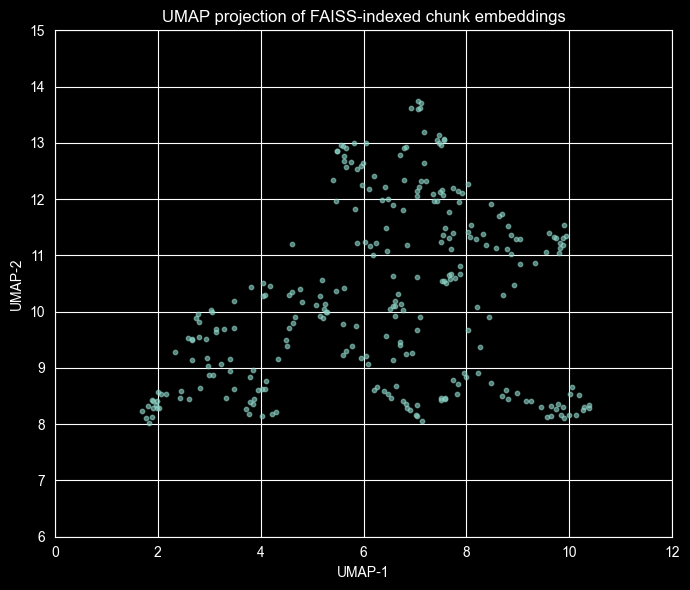

In [136]:
import numpy as np
import pandas as pd
import faiss
import umap
import matplotlib.pyplot as plt

DATA_DIR = (
    "/Users/djimra/MSc Data Science Jan 2025/Thesis documents/RAG_Pipeline_Project/"
    "data_processed/Grampian-2022-2023"
)

meta = pd.read_parquet(f"{DATA_DIR}/chunk_meta.parquet")
index = faiss.read_index(f"{DATA_DIR}/faiss.index")

X = index.reconstruct_n(0, index.ntotal)  # (n, d)

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="cosine",
    random_state=42
)

X_2d = reducer.fit_transform(X)

meta = meta.reset_index(drop=True)
meta["x"] = X_2d[:, 0]
meta["y"] = X_2d[:, 1]

plt.figure(figsize=(7, 6))
plt.scatter(meta["x"], meta["y"], s=10, alpha=0.6)

plt.xlim(0, 12)
plt.ylim(6, 15)
plt.title("UMAP projection of FAISS-indexed chunk embeddings")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()

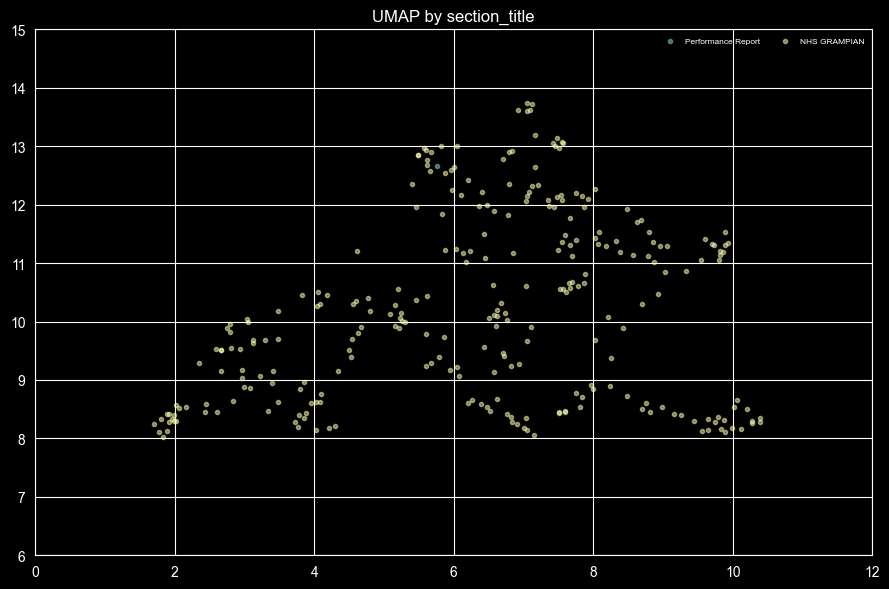

In [137]:
sec = meta["section_title"].fillna("unknown")

plt.figure(figsize=(9, 6))
for s in sec.unique():
    m = sec == s
    plt.scatter(meta.loc[m, "x"], meta.loc[m, "y"], s=9, alpha=0.5, label=s)

plt.legend(fontsize=6, ncol=2, frameon=False)
plt.xlim(0, 12)
plt.ylim(6, 15)
plt.title("UMAP by section_title")
plt.tight_layout()
plt.show()

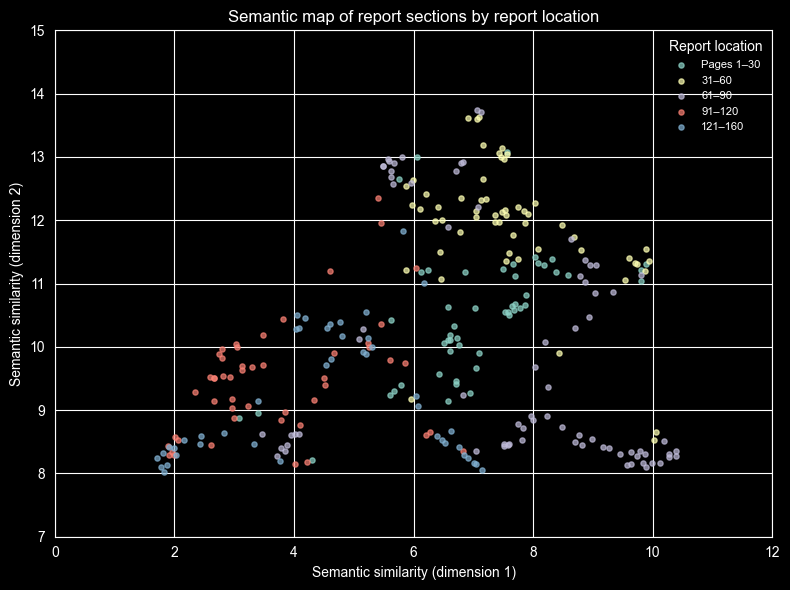

In [138]:
import pandas as pd
import matplotlib.pyplot as plt

# Define bins and human labels
bin_edges = [0, 30, 60, 90, 120, 160]
bin_labels = ["Pages 1–30", "31–60", "61–90", "91–120", "121–160"]

bins = pd.cut(
    meta["page_start"],
    bins=bin_edges,
    labels=bin_labels,
    include_lowest=True
)

plt.figure(figsize=(8, 6))

# Plot in a fixed order so legend order never changes
for lab in bin_labels:
    m = bins == lab
    plt.scatter(meta.loc[m, "x"], meta.loc[m, "y"], s=14, alpha=0.7, label=lab)

plt.legend(title="Report location", fontsize=8, frameon=False)

# Fixed display window for consistency across figures
plt.xlim(0, 12)
plt.ylim(7, 15)

plt.title("Semantic map of report sections by report location")
plt.xlabel("Semantic similarity (dimension 1)")
plt.ylabel("Semantic similarity (dimension 2)")

plt.tight_layout()
plt.show()

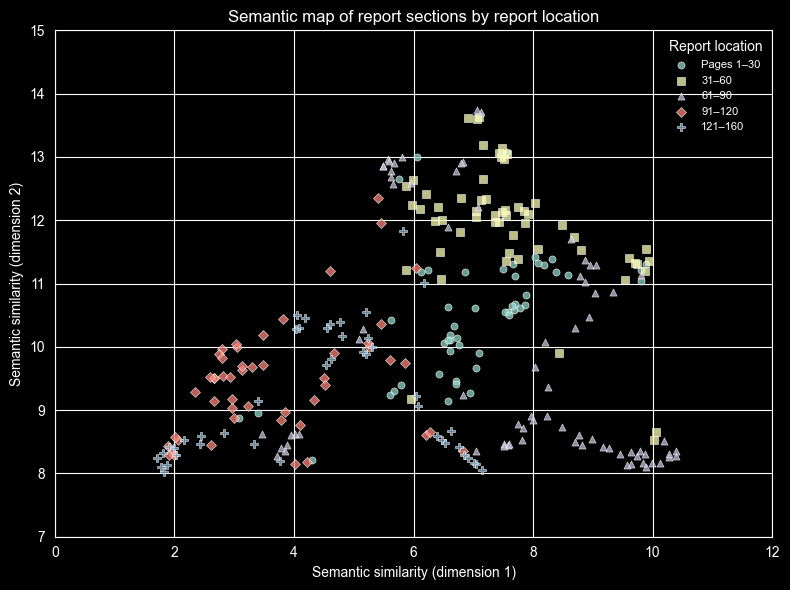

In [139]:
import pandas as pd
import matplotlib.pyplot as plt

bin_edges = [0, 30, 60, 90, 120, 160]
bin_labels = ["Pages 1–30", "31–60", "61–90", "91–120", "121–160"]

bins = pd.cut(
    meta["page_start"],
    bins=bin_edges,
    labels=bin_labels,
    include_lowest=True
)

markers = {
    "Pages 1–30": "o",   # circle
    "31–60": "s",        # square
    "61–90": "^",        # triangle up
    "91–120": "D",       # diamond
    "121–160": "P"       # plus-filled
}

plt.figure(figsize=(8, 6))

for lab in bin_labels:
    m = bins == lab
    plt.scatter(
        meta.loc[m, "x"],
        meta.loc[m, "y"],
        s=26,
        alpha=0.75,
        marker=markers[lab],
        edgecolors="white",   # outline for separation
        linewidths=0.5,
        label=lab
    )

plt.legend(title="Report location", fontsize=8, frameon=False)

plt.xlim(0, 12)
plt.ylim(7, 15)

plt.title("Semantic map of report sections by report location")
plt.xlabel("Semantic similarity (dimension 1)")
plt.ylabel("Semantic similarity (dimension 2)")

plt.tight_layout()
plt.show()